# 随机变量与条件概率

第016单元，先修007。使用精确分数、集合和有限总体枚举核对联合、条件、Bayes与独立；最后比较两个已定义小世界中的条件与干预。数据全部原创合成，不代表真实检查器性能。

## 设置

核心只用Python标准库。Notebook显示图需IPython，图已随课提供；不运行图生成器也能完成实验。重新启动内核后顺序执行，写notebook_outputs并覆盖该目录三个结果文件，不改data。

In [1]:
from pathlib import Path
from fractions import Fraction
from IPython.display import Image, display
from experiment import (load_table, OUTCOMES, bayes_flag, replacement_example,
                        xor_world, causal_world, run)
model=load_table()
print("population",model.total, "counts",model.counts)

population 1000 counts {(0, 0): 882, (0, 1): 98, (1, 0): 2, (1, 1): 18}


## 1 声明一次抽样的两个事件

抽样单位为编号，元组表示属性分组，顺序是缺陷、标记。

D 1/50
F 29/250
D and F 9/500
D or F 59/500


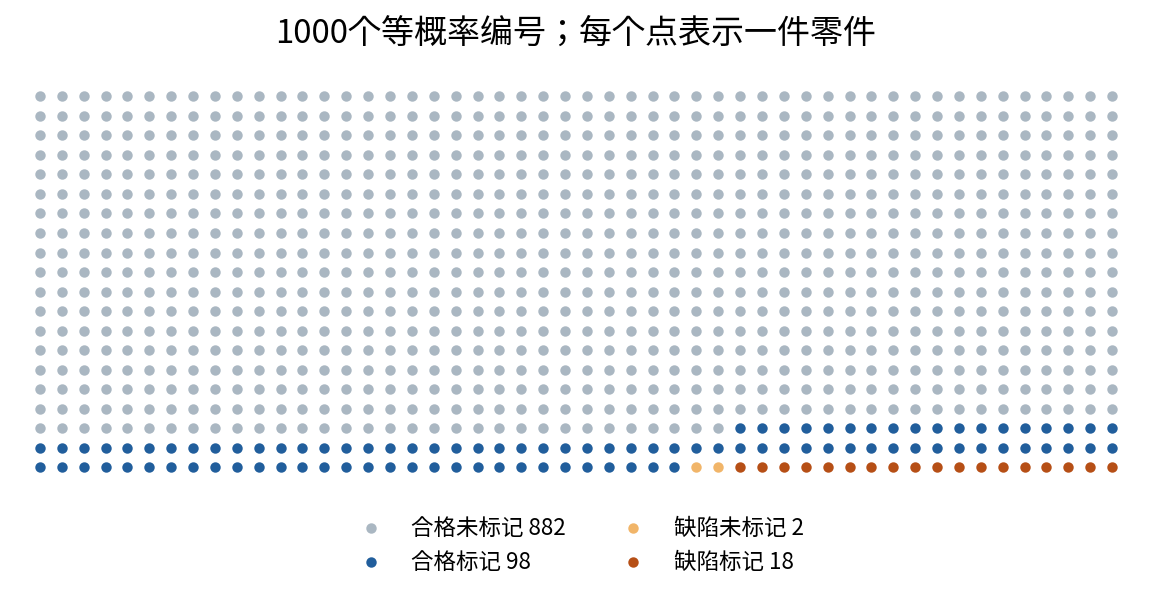

In [2]:
D={(1,0),(1,1)}
F={(0,1),(1,1)}
for name,event in [("D",D),("F",F),("D and F",D&F),("D or F",D|F)]:
    print(name,model.probability(event))
assert model.probability(D|F)==Fraction(59,500)
display(Image(filename="figures/01_table.png",width=700))

## 2 保留不同的条件分母

同一个交集除20或116，得到不同问题的答案；不能交换条件方向。

In [3]:
print("flag given defect",model.conditional(F,D))
print("defect given flag",model.conditional(D,F))
print("defect given no flag",model.conditional(D,OUTCOMES-F))
assert model.conditional(D,F)==Fraction(9,58)
assert model.conditional(D,OUTCOMES-F)==Fraction(1,442)

flag given defect 9/10
defect given flag 9/58
defect given no flag 1/442


## 3 从联合叶子重建分母和后验

路径乘边缘与条件，两种标记叶子互不重叠再相加。

{'prior': Fraction(1, 50), 'joint_defect_flag': Fraction(9, 500), 'joint_good_flag': Fraction(49, 500), 'flag_probability': Fraction(29, 250), 'posterior_defect_given_flag': Fraction(9, 58)}


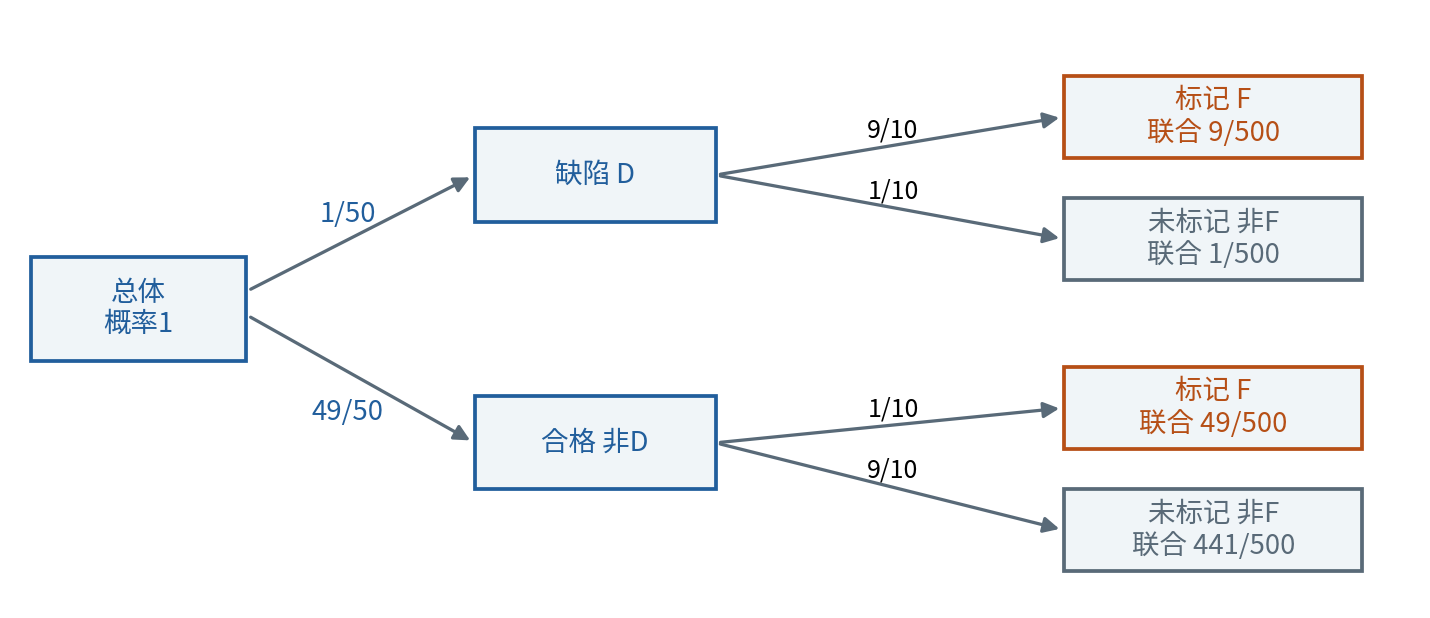

In [4]:
posterior=bayes_flag("1/50","9/10","1/10")
print(posterior)
assert posterior["joint_defect_flag"]+posterior["joint_good_flag"]==posterior["flag_probability"]
assert posterior["posterior_defect_given_flag"]==model.conditional(D,F)
display(Image(filename="figures/03_tree.png",width=760))

## 4 改先验但固定两种标记率

这是明确的模型假设扫描；没有测量真实环境改变后的检查器。

In [5]:
for prior in ("1/1000","1/100","1/50","1/10","1/2"):
    post=bayes_flag(prior,"9/10","1/10")["posterior_defect_given_flag"]
    print(prior,str(post),float(post))

1/1000 1/112 0.008928571428571428
1/100 1/12 0.08333333333333333
1/50 9/58 0.15517241379310345
1/10 1/2 0.5
1/2 9/10 0.9


## 5 用联合乘积核对独立

两个正概率事件互斥通常不独立；独立不能只看列名不同。

In [6]:
joint=model.probability(D&F)
product=model.probability(D)*model.probability(F)
print(joint,product)
assert not model.independent(D,F)
assert joint!=product

9/500 29/12500


## 6 两两独立和整体独立的区别

四个异或样本点穷尽该模型，所有结论可以精确枚举。

In [7]:
xor=xor_world()
for row in xor["rows"]:
    print(row)
print(xor["pairwise_independent"])
assert all(xor["pairwise_independent"].values())
assert xor["triple_111"]==0 and xor["product_of_three_marginals"]==Fraction(1,8)

{'x': 0, 'y': 0, 'z': 0, 'mass': Fraction(1, 4)}
{'x': 0, 'y': 1, 'z': 1, 'mass': Fraction(1, 4)}
{'x': 1, 'y': 0, 'z': 1, 'mass': Fraction(1, 4)}
{'x': 1, 'y': 1, 'z': 0, 'mass': Fraction(1, 4)}
{'xy': True, 'xz': True, 'yz': True}


## 7 更换抽样机制

区分编号和属性，枚举有序编号对；放回时独立重新选择。

In [8]:
draws=replacement_example()
print(draws)
assert draws["with_replacement"]["both_defective"]==Fraction(4,25)
assert draws["without_replacement"]["both_defective"]==Fraction(1,10)

{'with_replacement': {'ordered_pairs': 25, 'both_defective': Fraction(4, 25), 'second_given_first_defective': Fraction(2, 5)}, 'without_replacement': {'ordered_pairs': 20, 'both_defective': Fraction(1, 10), 'second_given_first_defective': Fraction(1, 4)}}


## 8 观察相同但干预不同

背景U保持原分布，干预只替换X的生成规则。

chain observed [{'u': 0, 'x': 0, 'y': 0, 'mass': Fraction(1, 2)}, {'u': 1, 'x': 1, 'y': 1, 'mass': Fraction(1, 2)}] do X=1 [{'u': 0, 'x': 1, 'y': 1, 'mass': Fraction(1, 2)}, {'u': 1, 'x': 1, 'y': 1, 'mass': Fraction(1, 2)}] P(Y=1) 1
common_cause observed [{'u': 0, 'x': 0, 'y': 0, 'mass': Fraction(1, 2)}, {'u': 1, 'x': 1, 'y': 1, 'mass': Fraction(1, 2)}] do X=1 [{'u': 0, 'x': 1, 'y': 0, 'mass': Fraction(1, 2)}, {'u': 1, 'x': 1, 'y': 1, 'mass': Fraction(1, 2)}] P(Y=1) 1/2


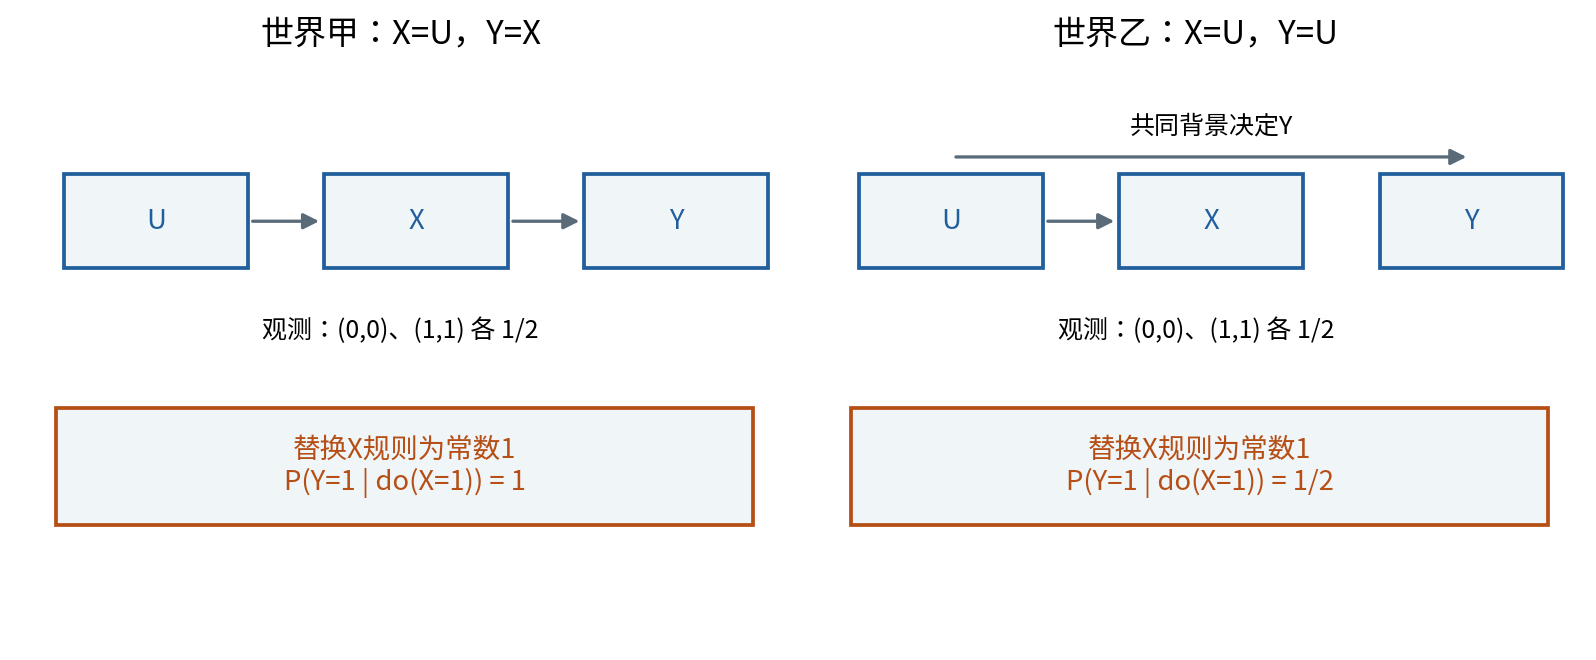

In [9]:
assert causal_world("chain")==causal_world("common_cause")
for name in ("chain","common_cause"):
    observed=causal_world(name)
    changed=causal_world(name,1)
    mass=sum(row["mass"] for row in changed if row["y"]==1)
    print(name, "observed",observed,"do X=1",changed,"P(Y=1)",mass)
display(Image(filename="figures/06_intervention.png",width=760))

## 9 无定义事件应明确拒绝

条件概率要求条件有正质量，空集合和非空零质量集合都不能作比例分母。

In [10]:
try:
    model.conditional(D,set())
except ValueError as error:
    print(str(error))
else:
    raise AssertionError("Zero-mass condition accepted")
from test_experiment import tests
checks=tests()
print(checks)
assert checks["status"]=="passed"

Conditional probability requires positive conditioning mass


{'status': 'passed', 'groups': 8, 'details': ['main joint marginal posterior and negative-flag hand results', '100 enumerated populations and all 256 event pairs per population', 'copied count ownership, duplicate event membership and exact prior scan', 'all ordered draws and pairwise versus joint independence', 'two observationally identical mechanisms under both interventions', '26 invalid table event probability and intervention rejections', 'byte-identical reruns and three malformed-copy CSV failures before output creation', '6 document Python snippets execute in order'], 'population_fixtures': 100, 'event_pairs': 25600, 'conditional_comparisons': 23424, 'bayes_comparisons': 98, 'rejected_cases': 26, 'malformed_csv_cases': 3, 'python_snippets': 6}


## 10 保存精确结果并与脚本核对

JSON同时保存分数字符串和展示小数，不把浮点展示值反过来当作精确基准。

In [11]:
report=run(Path("notebook_outputs"))
assert report["defect_given_flag"]==Fraction(9,58)
for name in ("results.json","prevalence_scan.csv","environment.json"):
    assert (Path("notebook_outputs")/name).read_bytes()==(Path("outputs")/name).read_bytes()
print("三份输出一致")

三份输出一致


## 下一步与边界

用lecture.pdf的12题和answers.pdf核对定义。随机性来自指定抽样实验，不是表格自发变化；实际总体、独立性及因果机制仍需要证据。已验证新进程真实InProcessKernel顺序执行，未测试浏览器Jupyter、跨进程socket或全新Anaconda。主例完全枚举，不使用随机模拟；测试seed仅重现额外夹具。